In [40]:
import pandas as pd
cells = pd.read_excel('all_anova_passed_cells_old.xlsx')
cells

,Unnamed: 0.1,Unnamed: 0,Date,Round No.,Time Window,Cell,P Value
0,51,NaN,2023-09-26,1,"(0.0, 300.0)",Channel.C_027_Unit 1,0.030966
1,0,0.0,2023-09-26,2,"(700.0, 1000.0)",Channel.C_011_Unit 1,0.022412
2,1,1.0,2023-09-26,2,"(50.0, 150.0)",Channel.C_020,0.004885
3,52,NaN,2023-09-26,3,"(0.0, 2000.0)",Channel.C_002_Unit 1,0.000105
4,2,2.0,2023-09-26,3,"(100.0, 200.0)",Channel.C_007_Unit 2,0.031938
...,...,...,...,...,...,...,...
70,46,46.0,2023-12-14,4,"(1900.0, 2000.0)",Channel.C_006,0.014833
71,47,47.0,2023-12-14,4,"(750.0, 850.0)",Channel.C_008,0.042302
72,48,48.0,2023-12-18,2,"(200.0, 350.0)",Channel.C_012_Unit 2,0.037932
73,49,49.0,2023-12-18,3,"(2000.0, 2150.0)",Channel.C_015_Unit 1,0.037427


In [41]:
from analyses.data_readers.recording_metadata_reader import RecordingMetadataReader
reader = RecordingMetadataReader()
prelim = reader.get_metadata_for_preliminary_analysis()
prelim

,Date,Round No.,Location
0,2023-09-26,1,Amygdala
1,2023-09-26,2,Amygdala
2,2023-09-26,3,Amygdala
3,2023-09-28,1,Amygdala
4,2023-09-29,2,Amygdala
5,2023-09-29,3,Amygdala
6,2023-09-29,4,Amygdala
7,2023-10-03,1,Amygdala
8,2023-10-03,3,Amygdala
9,2023-10-03,4,Amygdala


In [42]:
prelim['Location'] = prelim['Location'].replace({'Amygdala': 'AMG'})
prelim['Location'] = prelim['Location'].fillna('Unknown')
cells = cells.merge(
    prelim[['Date', 'Round No.', 'Location']],
    on=['Date', 'Round No.'],
    how='left'
)

# 3. 이제 NeuronID 생성
cells['NeuronID'] = (
    cells['Location'].astype(str) + "_" +
    cells['Date'].astype(str) + "_" +
    cells['Round No.'].astype(str) + "_" +
    cells['Cell'].astype(str))

In [43]:
cells['Time Window'] = cells['Time Window'].apply(
    lambda s: tuple(int(float(num)) for num in s.strip('()').split(',')))

In [44]:
# 튜플을 각각 분리
cells[['WindowStart_ms', 'WindowEnd_ms']] = cells['Time Window'].apply(pd.Series)


In [45]:
cells.drop(cells.columns[[0, 1]], axis=1, inplace=True)

In [46]:
cells

,Date,Round No.,Time Window,Cell,P Value,Location,NeuronID,WindowStart_ms,WindowEnd_ms
0,2023-09-26,1,"(0, 300)",Channel.C_027_Unit 1,0.030966,AMG,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300
1,2023-09-26,2,"(700, 1000)",Channel.C_011_Unit 1,0.022412,AMG,AMG_2023-09-26_2_Channel.C_011_Unit 1,700,1000
2,2023-09-26,2,"(50, 150)",Channel.C_020,0.004885,AMG,AMG_2023-09-26_2_Channel.C_020,50,150
3,2023-09-26,3,"(0, 2000)",Channel.C_002_Unit 1,0.000105,AMG,AMG_2023-09-26_3_Channel.C_002_Unit 1,0,2000
4,2023-09-26,3,"(100, 200)",Channel.C_007_Unit 2,0.031938,AMG,AMG_2023-09-26_3_Channel.C_007_Unit 2,100,200
...,...,...,...,...,...,...,...,...,...
70,2023-12-14,4,"(1900, 2000)",Channel.C_006,0.014833,ER,ER_2023-12-14_4_Channel.C_006,1900,2000
71,2023-12-14,4,"(750, 850)",Channel.C_008,0.042302,ER,ER_2023-12-14_4_Channel.C_008,750,850
72,2023-12-18,2,"(200, 350)",Channel.C_012_Unit 2,0.037932,Unknown,Unknown_2023-12-18_2_Channel.C_012_Unit 2,200,350
73,2023-12-18,3,"(2000, 2150)",Channel.C_015_Unit 1,0.037427,Unknown,Unknown_2023-12-18_3_Channel.C_015_Unit 1,2000,2150


In [47]:
from analyses.linear_regression.behavior_vector_linear_regression import \
    run_directional_vector_linear_regression_window_level
from analyses.spike_rate import compute_mean_spike_rate_for_windows
import os
from analyses.enums.monkey_names import get_monkeys_by_default_order

monkey_group = "Zombies"
subject_monkey_index = 6
monkey_list = get_monkeys_by_default_order(monkey_group)
base_dir = '/home/connorlab/Documents/GitHub/Julie//social_data/zombies_social_data/'
behavior_files = {
    "AffiliationTo": "zombies_feature_df_affiliation.xlsx",
    "AffiliationFrom": "zombies_feature_df_affiliation.xlsx",
    "SubmissionTo": "zombies_feature_df_submission.xlsx",
    "SubmissionFrom": "zombies_feature_df_submission.xlsx",
    "AgonismTo": "zombies_feature_df_agonism.xlsx",
    "AgonismFrom": "zombies_feature_df_agonism.xlsx",
}

behavior_matrices = {
    name: pd.read_excel(os.path.join(base_dir, fname)).iloc[:, 1:].to_numpy().T if 'From' in name
    else pd.read_excel(os.path.join(base_dir, fname)).iloc[:, 1:].to_numpy()
    for name, fname in behavior_files.items()
}



In [48]:
cells

,Date,Round No.,Time Window,Cell,P Value,Location,NeuronID,WindowStart_ms,WindowEnd_ms
0,2023-09-26,1,"(0, 300)",Channel.C_027_Unit 1,0.030966,AMG,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300
1,2023-09-26,2,"(700, 1000)",Channel.C_011_Unit 1,0.022412,AMG,AMG_2023-09-26_2_Channel.C_011_Unit 1,700,1000
2,2023-09-26,2,"(50, 150)",Channel.C_020,0.004885,AMG,AMG_2023-09-26_2_Channel.C_020,50,150
3,2023-09-26,3,"(0, 2000)",Channel.C_002_Unit 1,0.000105,AMG,AMG_2023-09-26_3_Channel.C_002_Unit 1,0,2000
4,2023-09-26,3,"(100, 200)",Channel.C_007_Unit 2,0.031938,AMG,AMG_2023-09-26_3_Channel.C_007_Unit 2,100,200
...,...,...,...,...,...,...,...,...,...
70,2023-12-14,4,"(1900, 2000)",Channel.C_006,0.014833,ER,ER_2023-12-14_4_Channel.C_006,1900,2000
71,2023-12-14,4,"(750, 850)",Channel.C_008,0.042302,ER,ER_2023-12-14_4_Channel.C_008,750,850
72,2023-12-18,2,"(200, 350)",Channel.C_012_Unit 2,0.037932,Unknown,Unknown_2023-12-18_2_Channel.C_012_Unit 2,200,350
73,2023-12-18,3,"(2000, 2150)",Channel.C_015_Unit 1,0.037427,Unknown,Unknown_2023-12-18_3_Channel.C_015_Unit 1,2000,2150


In [49]:
# Directional Linear Regression (OLS) on Significant Windows
sig_windows = cells
mean_spike_rate_windows = compute_mean_spike_rate_for_windows(sig_windows)
all_window_results = []
for name, mat in behavior_matrices.items():
    results_df = run_directional_vector_linear_regression_window_level(
        mean_spike_rate_windows, mat, name, monkey_group, monkey_list, subject_monkey_index, use_spikerate=True
    )
    all_window_results.append(results_df)

Computing windowed mean spike rate: 100%|██████████| 75/75 [00:00<00:00, 78.06it/s] 


In [50]:
all_window_results_df = pd.concat(all_window_results, ignore_index=True)

In [51]:
all_window_results_df

,NeuronID,WindowStart_ms,WindowEnd_ms,Behavior,Source_Monkey,Model,R-squared,coef,p_value
0,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,7124,ols,0.297116,-0.097158,0.162365
1,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,69X,ols,0.159603,-0.060525,0.326817
2,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,72X,ols,0.167999,-0.062581,0.313217
3,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,94B,ols,0.081236,-0.049410,0.493824
4,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,110E,ols,0.014496,-0.018241,0.776426
...,...,...,...,...,...,...,...,...,...
3397,Unknown_2023-12-18_3_Channel.C_020_Unit 1,150.0,400.0,AgonismFrom,110E,ols,0.106614,0.166843,0.429900
3398,Unknown_2023-12-18_3_Channel.C_020_Unit 1,150.0,400.0,AgonismFrom,67G,ols,0.000927,-0.014759,0.942934
3399,Unknown_2023-12-18_3_Channel.C_020_Unit 1,150.0,400.0,AgonismFrom,143H,ols,0.128365,-0.183073,0.383499
3400,Unknown_2023-12-18_3_Channel.C_020_Unit 1,150.0,400.0,AgonismFrom,87J,ols,0.051455,0.113172,0.589044


In [69]:
all_window_results_sorted = all_window_results_df.sort_values(by=['p_value','R-squared'], ascending=False)
filtered_df = all_window_results_df[
    (all_window_results_df['R-squared'] > 0.5)
    ]
# mean_spike_rate = compute_mean_spike_rate_for_windows(filtered_df)

In [70]:
summed_r2 = filtered_df.groupby('Source_Monkey')['R-squared'].sum().reset_index()

In [71]:
summed_r2

,Source_Monkey,R-squared
0,110E,15.974119
1,143H,9.663795
2,151J,18.845042
3,67G,13.687063
4,69X,6.133981
5,7124,12.869410
6,72X,6.249088
7,87J,14.870610
8,94B,12.177592


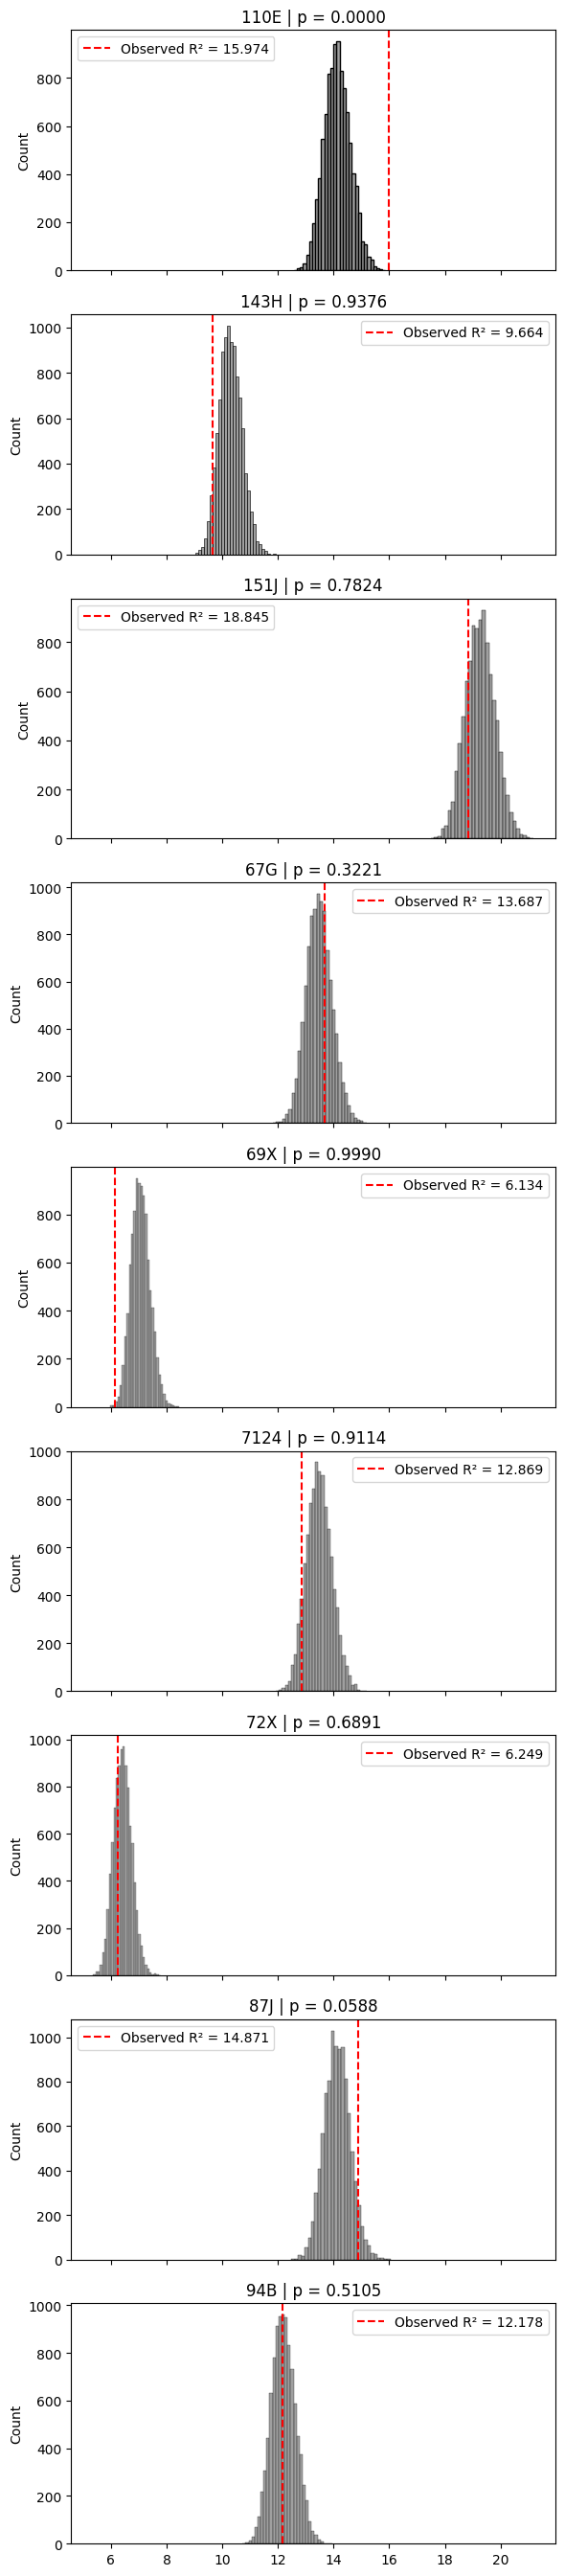

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline
# Settings
n_permutations = 10000
source_col = 'Source_Monkey'
r2_col = 'R-squared'
filtered_results = filtered_df
# Step 1: Observed R² sums
observed = filtered_results.groupby(source_col)[r2_col].sum()

# Step 2: Permutations
perm_sums = {monkey: [] for monkey in observed.index}

for _ in range(n_permutations):
    shuffled = filtered_df.copy()
    shuffled[source_col] = np.random.permutation(shuffled[source_col].values)
    permuted_sum = shuffled.groupby(source_col)[r2_col].sum()

    for monkey in observed.index:
        perm_sums[monkey].append(permuted_sum.get(monkey, 0))

# Step 3: Compute p-values
p_values = {}
for monkey in observed.index:
    perm_array = np.array(perm_sums[monkey])
    obs = observed[monkey]
    p = np.mean(perm_array >= obs)
    p_values[monkey] = p

# Step 4: Plot
fig, axs = plt.subplots(len(observed), 1, figsize=(6, 3 * len(observed)), sharex=True)

for i, monkey in enumerate(observed.index):
    ax = axs[i]
    sns.histplot(perm_sums[monkey], bins=30, kde=False, ax=ax, color='gray')
    ax.axvline(observed[monkey], color='red', linestyle='--', label=f"Observed R² = {observed[monkey]:.3f}")
    ax.set_title(f"{monkey} | p = {p_values[monkey]:.4f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [73]:
results = pd.read_pickle('saved_r2_permutation_results.pkl')

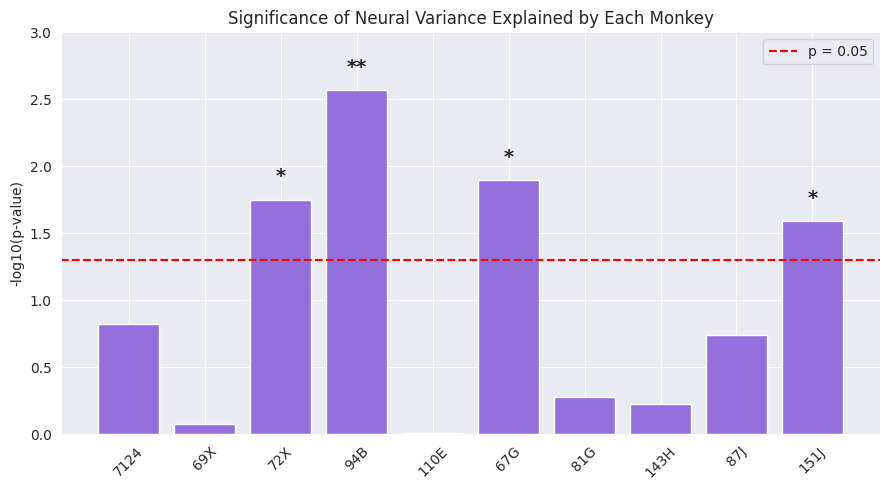

In [99]:
import matplotlib.pyplot as plt
import numpy as np

monkeys = ['7124', '69X', '72X', '94B', '110E', '67G', '81G', '143H', '87J', '151J']
sum_r2 = results['sumRsquared']
nless = results['nless']
n_perm = 10000

# p-value 계산
p_values = [(n_perm - n) / n_perm for n in nless]
neg_log_p = [-np.log10(p + 1e-6) for p in p_values]

# plot
plt.figure(figsize=(9, 5))
bars = plt.bar(monkeys, neg_log_p, color='mediumpurple')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')

# 별표 annotate
def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

for i, (bar, p) in enumerate(zip(bars, p_values)):
    star = get_star(p)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, star,
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylabel('-log10(p-value)')
plt.ylim(0,3)
plt.title('Significance of Neural Variance Explained by Each Monkey')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



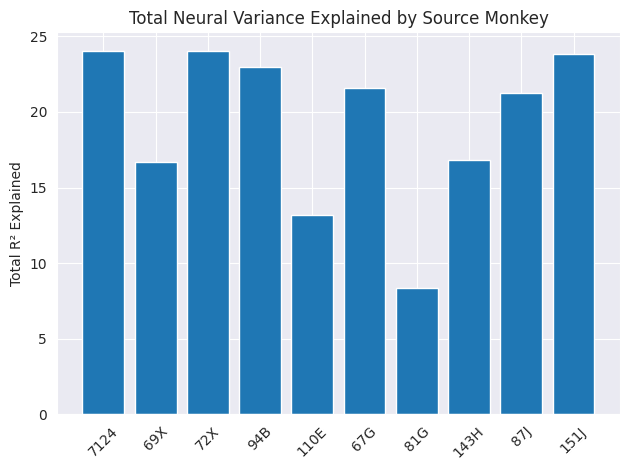

In [101]:

monkeys = ['7124', '69X', '72X', '94B', '110E', '67G', '81G', '143H', '87J', '151J']
plt.bar(monkeys, results['sumRsquared'])
plt.ylabel('Total R² Explained')
plt.title('Total Neural Variance Explained by Source Monkey')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

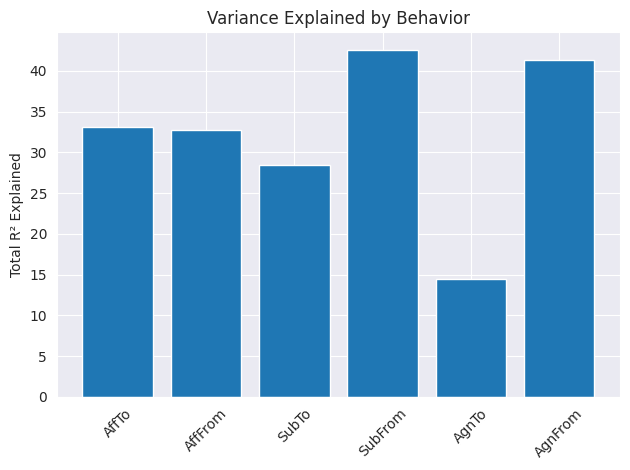

In [75]:
behaviors = ['AffTo', 'AffFrom', 'SubTo', 'SubFrom', 'AgnTo', 'AgnFrom']
plt.bar(behaviors, results['behsumRsquared'])
plt.ylabel('Total R² Explained')
plt.title('Variance Explained by Behavior')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

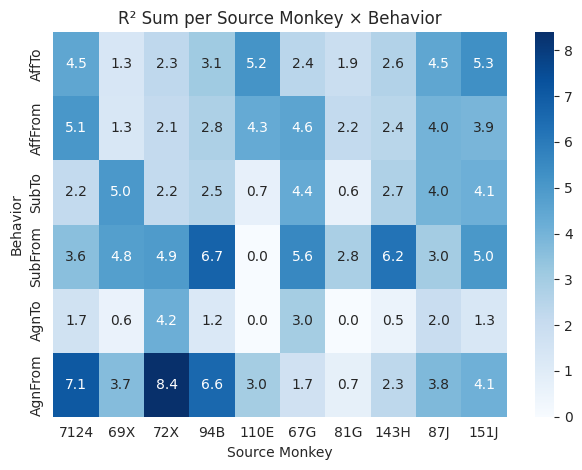

In [78]:
sns.heatmap(np.array(results['behmnksumRsquared']),
            xticklabels=monkeys,
            yticklabels=behaviors,
            annot=True, fmt=".1f", cmap='Blues')
plt.title('R² Sum per Source Monkey × Behavior')
plt.xlabel('Source Monkey')
plt.ylabel('Behavior')
plt.tight_layout()
plt.show()

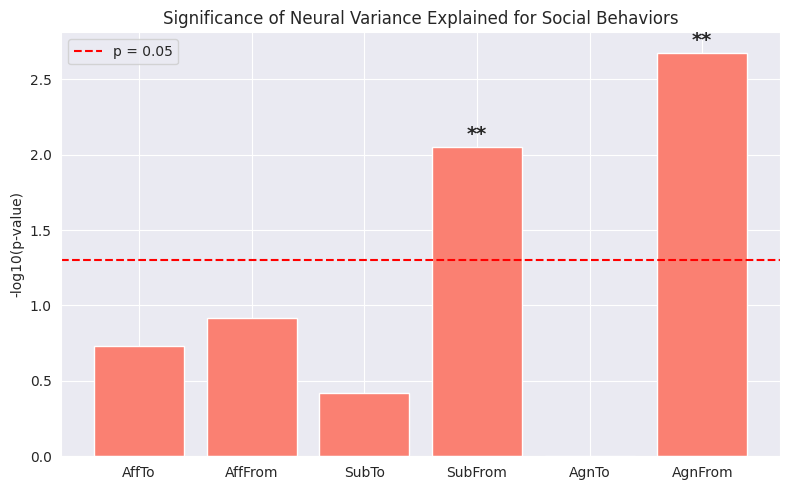

In [102]:
import numpy as np
import matplotlib.pyplot as plt

n_perm = 10000
behaviors = ['AffTo', 'AffFrom', 'SubTo', 'SubFrom', 'AgnTo', 'AgnFrom']
p_values = [(n_perm - n) / n_perm for n in results['nlessbehavior']]
neg_log_p = [-np.log10(p + 1e-6) for p in p_values]  # for plotting

# 별표 지정 함수
def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(behaviors, neg_log_p, color='salmon')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')

# 별표 annotate
for i, (bar, p) in enumerate(zip(bars, p_values)):
    star = get_star(p)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, star,
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylabel('-log10(p-value)')
plt.title('Significance of Neural Variance Explained for Social Behaviors')
plt.legend()
plt.tight_layout()
plt.show()



In [84]:
nlessbehavior

[8135, 8791, 6172, 9911, 58, 9979]